# Muse Glimmer-30B multimodal reasoning with OpenVINO™

[Muse Glimmer-30B](https://huggingface.co/meta-models/Muse-Glimmer-30B) is a dense multimodal model from Meta Superintelligence Lab designed for local agentic workloads. It combines a causal language model with a dedicated perception encoder and integrates multimodal understanding, multi-step reasoning, code generation, tool use, and failure recovery.

This tutorial shows how to convert and compress Muse Glimmer with Optimum Intel and NNCF, run image and video understanding through the OpenVINO GenAI `VLMPipeline`, inspect its ATEM reasoning channels, recreate a playable browser game from a reference image, and launch a multimodal Gradio chat.

> **Resource note:** Muse Glimmer contains approximately 29.6 billion parameters. INT4 is the recommended starting point, but conversion can still require more than 64 GB of system memory and substantial disk space.

⚠️ **EXPERIMENTAL NOTEBOOK**

This notebook demonstrates a model that has not been fully validated with OpenVINO. It may be fully supported and validated in the future.

### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Model capabilities](#Model-capabilities)
- [Select compression and reasoning strength](#Select-compression-and-reasoning-strength)
- [Convert and compress the model](#Convert-and-compress-the-model)
- [Select inference device](#Select-inference-device)
- [Create the OpenVINO GenAI pipeline](#Create-the-OpenVINO-GenAI-pipeline)
- [Understand the ATEM response format](#Understand-the-ATEM-response-format)
- [Image understanding](#Image-understanding)
- [Video understanding](#Video-understanding)
- [Create a browser game from an image](#Create-a-browser-game-from-an-image)
- [Create a browser game without an image](#Create-a-browser-game-without-an-image)
- [Run the Gradio demo](#Run-the-Gradio-demo)

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/muse-glimmer/muse-glimmer.ipynb" />

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

Install the required packages. Muse Glimmer support requires `transformers==5.15`, Optimum Intel from its current main branch, NNCF 3.3, and recent OpenVINO GenAI packages.

In [ ]:
import os

os.environ["GIT_CLONE_PROTECTION_ACTIVE"] = "false"

%pip install -q -U --pre "openvino>=2026.0.0" openvino-tokenizers openvino-genai --extra-index-url https://storage.openvinotoolkit.org/simple/wheels/nightly
%pip install -q --extra-index-url https://download.pytorch.org/whl/cpu \
"git+https://github.com/huggingface/optimum-intel.git" \
"nncf==3.3.0" \
"transformers==5.15" \
"torch>=2.1" \
"datasets<4.0.0" \
"accelerate" \
"gradio>=6.0" \
"huggingface-hub>=0.26.5" \
"opencv-python-headless" \
"einops" \
"timm" \
"sentencepiece"

In [2]:
import os
import shutil
from pathlib import Path

import requests

# Reuse the shared model configuration when running from the repository.
config_shared_path = Path("../../utils/llm_config.py")
config_path = Path("llm_config.py")

if config_shared_path.exists():
    if config_path.exists() and not config_path.is_symlink():
        shutil.copy(config_shared_path, config_path)
    elif not config_path.exists():
        try:
            os.symlink(config_shared_path, config_path)
        except OSError:
            shutil.copy(config_shared_path, config_path)
elif not config_path.exists():
    response = requests.get(
        "https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/llm_config.py",
        timeout=30,
    )
    response.raise_for_status()
    config_path.write_text(response.text, encoding="utf-8")

if not Path("notebook_utils.py").exists():
    response = requests.get(
        "https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
        timeout=30,
    )
    response.raise_for_status()
    Path("notebook_utils.py").write_text(response.text, encoding="utf-8")

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("muse-glimmer.ipynb")

## Model capabilities
[back to top ⬆️](#Table-of-contents:)

Muse Glimmer is a dense causal transformer with approximately 29.6 billion parameters, including a dedicated perception encoder. Important characteristics include:

- **Multimodal reasoning:** interleaved text and images, plus frame-based video understanding in this OpenVINO example.
- **Agentic behavior:** multi-step reasoning, structured tool use, coding, and recovery from failed actions.
- **Long context:** a reported context length of 131,072 tokens or more.
- **Controllable effort:** `low`, `medium`, `high`, and `xhigh` reasoning strengths balance latency and quality.
- **ATEM channels:** internal reasoning is emitted to `self`, while the final response is emitted to `user`.
- **Multilingual input:** training data includes more than 100 languages.

The model card recommends `temperature=1.0`, `top_p=0.95`, and `top_k=64`. The examples use low reasoning for visual description and code generation so that most of the generation budget remains available for the final answer. Higher strengths are better suited to complex agentic tasks with a larger token budget.

## Select compression and reasoning strength
[back to top ⬆️](#Table-of-contents:)

The shared VLM conversion helper uses `image-text-to-text`. For Muse Glimmer, INT4 export applies asymmetric quantization with group size 64 and `group_size_fallback=ignore`. Preconverted OpenVINO models are used automatically when available; otherwise the model is exported locally.

Reasoning strength controls how long the model thinks before entering its final `to=user` channel. `low` is recommended for the examples because it leaves more tokens for image descriptions and generated code. `high` and `xhigh` can improve difficult reasoning tasks but require a larger generation budget.

In [3]:
import ipywidgets as widgets
from IPython.display import display

from llm_config import SUPPORTED_VLM_MODELS

model_id = "Muse-Glimmer-30B"
model_configuration = SUPPORTED_VLM_MODELS["English"][model_id]

compression = widgets.Dropdown(
    options=["INT4", "INT8", "FP16"],
    value="INT4",
    description="Compression:",
)
use_preconverted = widgets.Checkbox(
    value=True,
    description="Use preconverted model when available",
    indent=False,
)
reasoning_strength = widgets.Dropdown(
    options=["low", "medium", "high", "xhigh"],
    value="low",
    description="Reasoning:",
)

display(compression, use_preconverted, reasoning_strength)

Dropdown(description='Compression:', options=('INT4', 'INT8', 'FP16'), value='INT4')

Checkbox(value=True, description='Use preconverted model when available', indent=False)

Dropdown(description='Reasoning:', options=('low', 'medium', 'high', 'xhigh'), value='low')

## Convert and compress the model
[back to top ⬆️](#Table-of-contents:)

Optimum Intel exports the model into separate language, text-embedding, and vision-embedding OpenVINO IR components. The first conversion can take a long time and requires enough memory to load and compress the original model.

In [4]:
from llm_config import compare_model_size, convert_and_compress_vlm

model_dir = convert_and_compress_vlm(
    model_id,
    model_configuration,
    compression.value,
    use_preconverted.value,
)
compare_model_size(model_dir)

✅ INT4 Muse-Glimmer-30B VLM model already converted and can be found in Muse-Glimmer-30B/INT4_compressed_weights
Size of model with INT4 compressed weights is 14224.84 MB


## Select inference device
[back to top ⬆️](#Table-of-contents:)

This experimental notebook currently exposes CPU only. GPU and NPU execution are intentionally excluded until they are validated for this model.

In [5]:
from notebook_utils import device_widget

device = device_widget(default="CPU", exclude=["AUTO", "GPU", "NPU"])
device

Dropdown(description='Device:', options=('CPU',), value='CPU')

## Create the OpenVINO GenAI pipeline
[back to top ⬆️](#Table-of-contents:)

`VLMPipeline` loads the exported language and vision components and provides one API for text, image, and video requests. The helper functions imported below also understand Muse Glimmer's ATEM response format.

In [6]:
import time

import numpy as np
import openvino as ov
import openvino_genai as ov_genai
from PIL import Image

from gradio_helper import (
    generate_with_streaming,
    load_video_frames,
    split_atem_response,
)

load_started = time.time()
pipe = ov_genai.VLMPipeline(str(model_dir), device.value)
print(f"Model loaded in {time.time() - load_started:.2f} seconds")

description_token_budgets = {
    "low": 1024,
    "medium": 2048,
    "high": 4096,
    "xhigh": 8192,
}
game_token_budgets = {
    "low": 8192,
    "medium": 12288,
    "high": 16384,
    "xhigh": 24576,
}

base_config = ov_genai.GenerationConfig()
base_config.temperature = 1.0
base_config.top_p = 0.95
base_config.top_k = 64
base_config.do_sample = True

Model loaded in 7.47 seconds


## Understand the ATEM response format
[back to top ⬆️](#Table-of-contents:)

Muse Glimmer uses separate recipients for internal reasoning and the user-facing response. OpenVINO GenAI returns decoded output similar to:

```text
to=self ...reasoning... assistant to=user ...final answer...
```

The special channel tokens are removed during decoding, but the recipient markers remain. `generate_with_streaming` accumulates partial output so channel markers can span multiple chunks. While the model reasons, an expanded **Reasoning** accordion and character counter update continuously. When `to=user` appears, the accordion collapses and the final answer continues streaming below it.

## Image understanding
[back to top ⬆️](#Table-of-contents:)

First, ask the model to describe a photograph. Low reasoning strength is sufficient for direct visual description.

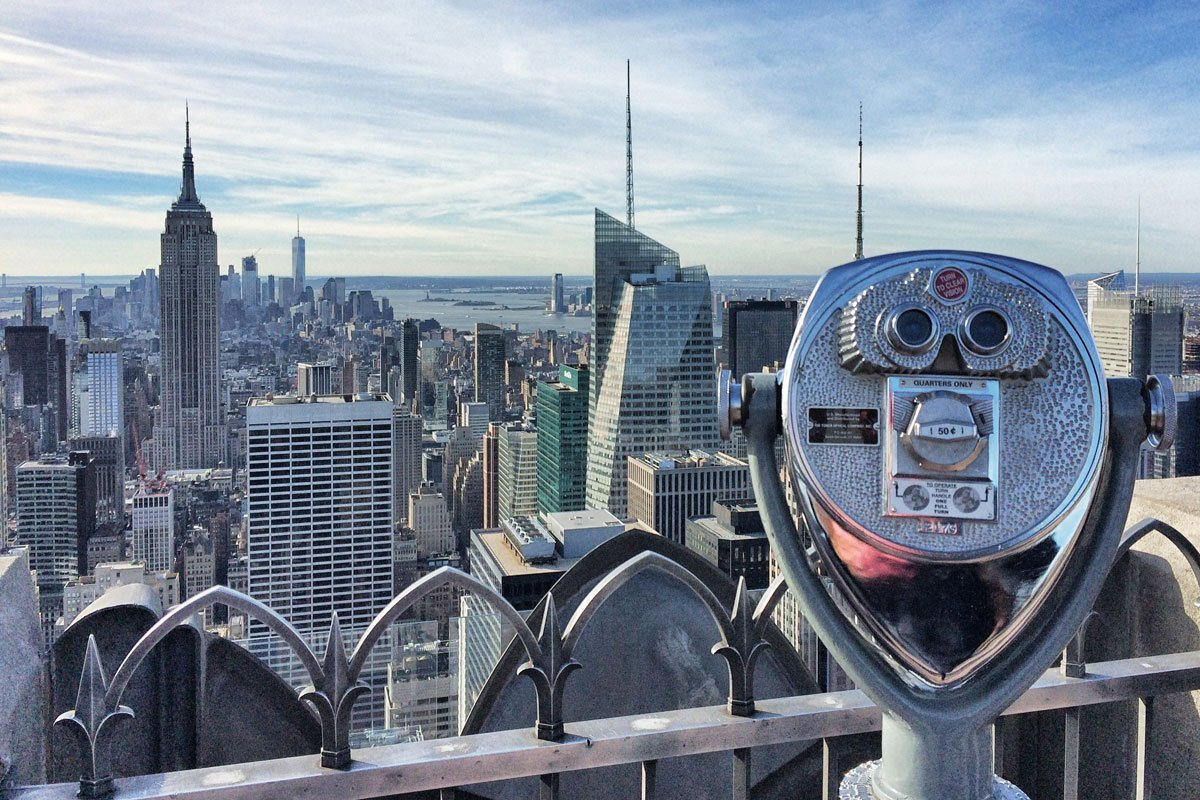

HTML(value='<b>Generating:</b> waiting for the first token…')

Accordion(children=(HTML(value='<i>Waiting for reasoning…</i>'),), selected_index=0, titles=('Reasoning (strea…

The photo is a daytime view from a high observation deck looking out over Midtown Manhattan, New York City.

In the immediate foreground on the right is a classic street-level/observation-deck coin-operated binocular viewer, the kind marked “Quarters Only” and “50¢”, mounted on a gray metal pedestal. Its shiny chrome face and two eyepieces are in sharp focus, and a small red “Turn Coin Here” sticker is visible on top. In front of it is a decorative metal railing with fleur-de-lis finials and the dark stone parapet of the deck.

Beyond the railing the cityscape stretches out under a pale blue sky with wispy high clouds. On the left the iconic Art Deco spire of the Empire State Building dominates the skyline, with its setbacks clearly visible. To its right, slightly further in the distance, the slender tower of One World Trade Center rises above the dense cluster of mid-rise and high-rise buildings. 

Center-right is a modern glass skyscraper with a distinctive angled roof and a tall spire – 121 West 42nd Street / the Hearst Tower area – and further right more glass office towers are visible. In the far background the Hudson River / Upper New York Bay is visible with a distant landmass, and the city grid recedes toward the horizon.

The viewpoint, the ornate railing and the view of the Empire State Building from the south/southwest, is characteristic of the Top of the Rock observation deck at Rockefeller Center, looking south over Midtown Manhattan toward Lower Manhattan and the water.

Inference time: 177.41 seconds


In [7]:
from notebook_utils import download_file

image_path = Path("nyc.jpg")
if not image_path.exists():
    download_file(
        "https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/vlm-chatbot/nyc.jpg",
        filename=image_path.name,
        directory=image_path.parent,
    )

display(Image.open(image_path))
image_tensor = ov.Tensor(np.asarray(Image.open(image_path).convert("RGB")))

base_config.max_new_tokens = description_token_budgets[reasoning_strength.value]
started = time.time()
image_response = generate_with_streaming(
    pipe,
    "Describe this image. Identify the main objects and the setting.",
    reasoning_strength=reasoning_strength.value,
    image=image_tensor,
    generation_config=base_config,
)
print(f"Inference time: {time.time() - started:.2f} seconds")

## Video understanding
[back to top ⬆️](#Table-of-contents:)

OpenVINO GenAI accepts a video as an `ov.Tensor` with layout `[Frame, H, W, C]`. The helper samples eight frames uniformly and preserves OpenCV's BGR channel order expected by the video pipeline.

In [8]:
video_dir = Path("data")
video_dir.mkdir(parents=True, exist_ok=True)
video_path = video_dir / "coco.mp4"

if not video_path.exists():
    download_file(
        "https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/video/Coco%20Walking%20in%20Berkeley.mp4",
        filename=video_path.name,
        directory=video_dir,
    )

frames_tensor = load_video_frames(video_path, max_frames=8)
print(f"Loaded {frames_tensor.shape[0]} frames at " f"{frames_tensor.shape[2]}x{frames_tensor.shape[1]}")

base_config.max_new_tokens = description_token_budgets[reasoning_strength.value]
started = time.time()
video_response = generate_with_streaming(
    pipe,
    "Describe what is happening in this video.",
    reasoning_strength=reasoning_strength.value,
    videos=[frames_tensor],
    generation_config=base_config,
)
print(f"Inference time: {time.time() - started:.2f} seconds")

Loaded 8 frames at 640x360


HTML(value='<b>Generating:</b> waiting for the first token…')

Accordion(children=(HTML(value='<i>Waiting for reasoning…</i>'),), selected_index=0, titles=('Reasoning (strea…

In the clip a dark chocolate-brown dog — a Labrador-type mix on a black leash with a purple / patterned collar — is being walked along a concrete sidewalk that runs alongside a plain white building wall.

The dog is on the left side of the frame at first, walking leftward across the pavement with its tail up, nose down as if sniffing the ground. A bit of the handler is visible at the right edge of the frame: brown pants and a light-blue athletic shoe. The leash trails from the dog’s collar up to the handler off-screen.

The dog continues a few steps, keeps its head low, then slows and lowers itself into a sit on the sidewalk, turning its head up to look at the person holding the leash. The background is a plain light-gray concrete wall with a small recessed doorway/alcove and a few bits of litter on the ground. The lighting is overcast daylight.

Inference time: 110.93 seconds


## Create a browser game from an image
[back to top ⬆️](#Table-of-contents:)

This example exercises visual coding rather than ordinary image captioning. We create a compact Breakout mockup, pass it as a visual specification, and ask Muse Glimmer to reproduce its layout and colors as a playable single-file HTML5 game.

Breakout is used instead of Snake because a single frame exposes more of the intended mechanics: the brick field, ball, paddle, score, lives, and play area are all directly visible. The generated code is rendered in a sandboxed iframe and cannot access the notebook page.

> **Tip:** keep **Reasoning** set to `low` for this example. Higher levels can spend most of `max_new_tokens` on the reasoning channel before the model finishes the HTML.

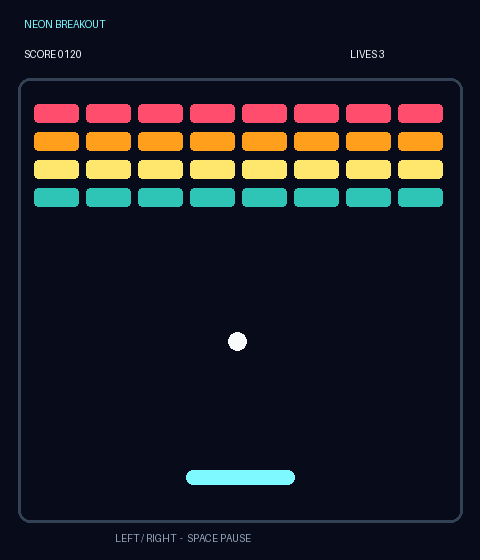

In [9]:
from PIL import ImageDraw

reference_size = (480, 560)
reference = Image.new("RGB", reference_size, "#070b1a")
draw = ImageDraw.Draw(reference)

# Header and play-field frame.
draw.text((24, 18), "NEON BREAKOUT", fill="#7df9ff")
draw.text((24, 48), "SCORE 0120", fill="#f8fafc")
draw.text((350, 48), "LIVES 3", fill="#f8fafc")
draw.rounded_rectangle((18, 78, 462, 522), radius=12, outline="#334155", width=3)

brick_colors = ["#ff4d6d", "#ff9f1c", "#ffe66d", "#2ec4b6"]
for row, color in enumerate(brick_colors):
    for column in range(8):
        left = 34 + column * 52
        top = 104 + row * 28
        draw.rounded_rectangle(
            (left, top, left + 44, top + 18),
            radius=4,
            fill=color,
        )

# Ball, paddle, and controls.
draw.ellipse((228, 332, 246, 350), fill="#f8fafc")
draw.rounded_rectangle((186, 470, 294, 484), radius=7, fill="#7df9ff")
draw.text((115, 532), "LEFT / RIGHT  -  SPACE PAUSE", fill="#94a3b8")

reference_path = Path("breakout_reference.png")
reference.save(reference_path)
display(reference)

In [10]:
import html as html_lib
import re

from IPython.display import IFrame

game_prompt = """
The attached image is a visual specification for a browser game. Recreate it as a complete, playable, single-file HTML5 Breakout game.

Requirements:
- Return only the complete HTML document, starting with <!DOCTYPE html>; do not explain it.
- Keep internal reasoning brief and prioritize completing the code in the final to=user response.
- Use a 480x560 canvas and match the dark neon layout, brick colors, score, lives, paddle, and labels visible in the image.
- Use no external libraries, network resources, fonts, images, or audio.
- Move the paddle with Left/Right or A/D; pause with Space.
- Implement ball movement, wall/paddle/brick collisions, score, three lives, win/game-over states, and restart with Enter.
- Canvas Y coordinates increase downward. Handle a paddle hit only while the ball is descending and crossing the paddle top; then place the ball immediately above the paddle and set its vertical velocity to a negative value such as -Math.abs(ball.vy), so it always bounces upward instead of rolling off.
- Use requestAnimationFrame for the game loop.
- Do not use alert(), confirm(), or prompt().
""".strip()

game_config = ov_genai.GenerationConfig()
game_config.max_new_tokens = game_token_budgets[reasoning_strength.value]
game_config.temperature = 1.0
game_config.top_p = 0.95
game_config.top_k = 64
game_config.do_sample = True

reference_tensor = ov.Tensor(np.asarray(reference))
started = time.time()
game_response = generate_with_streaming(
    pipe,
    game_prompt,
    reasoning_strength=reasoning_strength.value,
    show_answer=False,
    image=reference_tensor,
    generation_config=game_config,
)
reasoning, answer, _ = split_atem_response(game_response)

if not answer:
    raise RuntimeError(
        "Muse Glimmer exhausted the generation budget before producing a final to=user answer. " "Increase game_config.max_new_tokens and retry."
    )

fenced_html = re.search(r"```(?:html)?\s*(.*?)```", answer, flags=re.IGNORECASE | re.DOTALL)
game_html = fenced_html.group(1).strip() if fenced_html else answer.strip()
if "<!DOCTYPE html>" in game_html:
    game_html = game_html[game_html.index("<!DOCTYPE html>") :]
elif "<html" in game_html.lower():
    game_html = game_html[game_html.lower().index("<html") :]

required_fragments = ("<canvas", "<script", "keydown", "requestAnimationFrame", "</html>")
missing = [fragment for fragment in required_fragments if fragment.lower() not in game_html.lower()]
if missing:
    raise ValueError(
        "Generated HTML is incomplete, most likely because max_new_tokens was exhausted. "
        f"Missing: {', '.join(missing)}. Generated length: {len(game_html):,} characters."
    )

output_path = Path("generated_breakout.html")
output_path.write_text(game_html, encoding="utf-8")
print(f"Generated {len(game_html):,} characters in {time.time() - started:.2f} seconds")
print(f"Saved to {output_path.resolve()}")

escaped_game = html_lib.escape(game_html, quote=True)
display(
    IFrame(
        src="about:blank",
        width=520,
        height=610,
        extras=[
            'sandbox="allow-scripts"',
            f'srcdoc="{escaped_game}"',
            'style="border:1px solid #334155; border-radius:12px"',
        ],
    )
)

HTML(value='<b>Generating:</b> waiting for the first token…')

Accordion(children=(HTML(value='<i>Waiting for reasoning…</i>'),), selected_index=0, titles=('Reasoning (strea…

Generated 5,249 characters in 637.03 seconds
Saved to /home/maleksandr/test_notebooks/july-17/openvino_notebooks/notebooks/muse-glimmer/generated_breakout.html


## Create a browser game without an image
[back to top ⬆️](#Table-of-contents:)

This example generates a Snake game from text only. It demonstrates Muse Glimmer's code generation capabilities using the same ATEM reasoning and streaming output, without visual input.

In [11]:
import html as html_lib
import re

from IPython.display import IFrame

snake_prompt = """
Create a complete, playable, single-file HTML5 Snake game.

Requirements:
- Return only the complete HTML document, starting with <!DOCTYPE html>; do not explain it.
- Keep internal reasoning brief and prioritize completing the code in the final to=user response.
- Use a 420x480 canvas with a dark theme, neon green snake, red food, score, and high-score display.
- Use no external libraries, network resources, fonts, images, or audio.
- The game runs in an iframe sandbox without allow-same-origin. Do not use localStorage, sessionStorage, IndexedDB, cookies, or any persistent browser storage; keep the high score in a JavaScript variable.
- Control the snake with Arrow keys or WASD; pause with Space.
- Implement food placement, growth, increasing speed, wall and self collisions, game-over state, and restart with Enter.
- Apply the queued direction before calculating the next head position.
- Use requestAnimationFrame for the game loop.
- Do not use alert(), confirm(), or prompt().
""".strip()

text_game_config = ov_genai.GenerationConfig()
text_game_config.max_new_tokens = game_token_budgets[reasoning_strength.value]
text_game_config.temperature = 1.0
text_game_config.top_p = 0.95
text_game_config.top_k = 64
text_game_config.do_sample = True

started = time.time()
snake_response = generate_with_streaming(
    pipe,
    snake_prompt,
    reasoning_strength=reasoning_strength.value,
    show_answer=False,
    generation_config=text_game_config,
)
_, snake_answer, _ = split_atem_response(snake_response)

if not snake_answer:
    raise RuntimeError(
        "Muse Glimmer exhausted the generation budget before producing a final to=user answer. " "Increase text_game_config.max_new_tokens and retry."
    )

fenced_html = re.search(r"```(?:html)?\s*(.*?)```", snake_answer, flags=re.IGNORECASE | re.DOTALL)
snake_html = fenced_html.group(1).strip() if fenced_html else snake_answer.strip()
if "<!DOCTYPE html>" in snake_html:
    snake_html = snake_html[snake_html.index("<!DOCTYPE html>") :]
elif "<html" in snake_html.lower():
    snake_html = snake_html[snake_html.lower().index("<html") :]

required_fragments = ("<canvas", "<script", "keydown", "requestAnimationFrame", "</html>")
missing = [fragment for fragment in required_fragments if fragment.lower() not in snake_html.lower()]
if missing:
    raise ValueError(
        "Generated HTML is incomplete, most likely because max_new_tokens was exhausted. "
        f"Missing: {', '.join(missing)}. Generated length: {len(snake_html):,} characters."
    )

forbidden_storage = ("localStorage", "sessionStorage", "indexedDB")
used_storage = [name for name in forbidden_storage if name.lower() in snake_html.lower()]
if used_storage:
    raise ValueError("Generated game uses browser storage that is unavailable in the sandboxed iframe: " f"{', '.join(used_storage)}. Regenerate the game.")

snake_output_path = Path("generated_snake.html")
snake_output_path.write_text(snake_html, encoding="utf-8")
print(f"Generated {len(snake_html):,} characters in {time.time() - started:.2f} seconds")
print(f"Saved to {snake_output_path.resolve()}")

escaped_snake = html_lib.escape(snake_html, quote=True)
display(
    IFrame(
        src="about:blank",
        width=460,
        height=560,
        extras=[
            'sandbox="allow-scripts"',
            f'srcdoc="{escaped_snake}"',
            'style="border:1px solid #334155; border-radius:12px"',
        ],
    )
)

HTML(value='<b>Generating:</b> waiting for the first token…')

Accordion(children=(HTML(value='<i>Waiting for reasoning…</i>'),), selected_index=0, titles=('Reasoning (strea…

Generated 4,805 characters in 556.46 seconds
Saved to /home/maleksandr/test_notebooks/july-17/openvino_notebooks/notebooks/muse-glimmer/generated_snake.html


## Run the Gradio demo
[back to top ⬆️](#Table-of-contents:)

The interactive demo accepts text, images, and video. During streaming it accumulates the decoded ATEM output, displays the `to=self` channel as a collapsible **Reasoning** message, and starts a separate assistant message when the `to=user` channel appears.

Reasoning strength can be selected before starting a new conversation. Press **Clear** before changing it for an existing conversation.

In [ ]:
from gradio_helper import make_demo

demo = make_demo(
    pipe,
    sample_image=reference_path,
    sample_video=video_path,
)

try:
    demo.launch(debug=True)
except Exception:
    demo.launch(debug=True, share=True)